# K-Means Clustering — Exercise Solutions

## Step 1 — Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)
print("Libraries imported successfully.")

Libraries imported successfully.


## Step 2 — Create and Explore the Dataset

In [16]:
# Data creation — do not modify
def make_gym_data(n=240):
    rng = np.random.default_rng(7)
    segments = [
        (4,  28, 0.25),
        (16, 30, 0.25),
        (5,  75, 0.25),
        (18, 80, 0.25),
    ]
    rows = []
    for visit_mean, mins_mean, frac in segments:
        size    = int(n * frac)
        visits  = rng.normal(visit_mean, 1.5, size).clip(1, 25)
        minutes = rng.normal(mins_mean,  8,   size).clip(10, 120)
        rows.append(np.column_stack([visits, minutes]))
    data = np.vstack(rows)
    return pd.DataFrame(data, columns=['visits_per_month', 'avg_session_minutes'])

df = make_gym_data(n=240)
print("Dataset created.")

Dataset created.


In [17]:
# 1. First 5 rows
df.head()

,visits_per_month,avg_session_minutes
0,4.001845,29.625109
1,4.448118,24.293539
2,3.588793,29.018147
3,2.664112,18.502444
4,3.317994,23.365587


In [18]:
# 2. Shape
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")

Shape: 240 rows × 2 columns


In [19]:
# 3. Summary statistics
df.describe().round(2)

,visits_per_month,avg_session_minutes
count,240.00,240.00
mean,10.55,52.39
std,6.48,25.06
min,1.00,11.72
25%,4.31,28.57
50%,10.20,54.23
75%,16.56,75.39
max,21.81,94.89


In [20]:
# 4. Missing values
print("Missing values:")
print(df.isnull().sum())

Missing values:
visits_per_month       0
avg_session_minutes    0
dtype: int64


**Reflection answer:** The dataset has 240 members and 2 columns. `visits_per_month` ranges roughly from 1 to 25, and `avg_session_minutes` from about 10 to 120. There are no missing values. Looking at the ranges and spread, you can already suspect around 4 groups: low visits/short sessions, high visits/short sessions, low visits/long sessions, and high visits/long sessions.

## Step 3- Plot the Raw Data

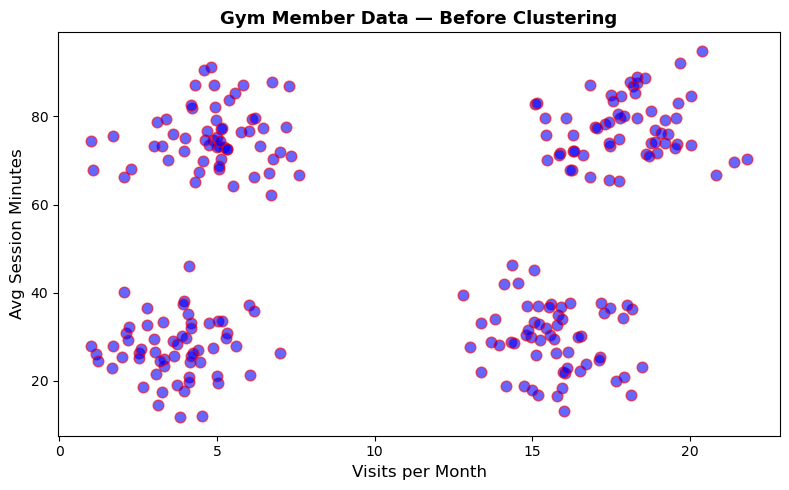

In [27]:
plt.figure(figsize=(8, 5))
plt.scatter(df['visits_per_month'], df['avg_session_minutes'],
                color='blue', alpha=0.6, edgecolors='red', s=60)
plt.xlabel('Visits per Month', fontsize=12)
plt.ylabel('Avg Session Minutes', fontsize=12)
plt.title('Gym Member Data — Before Clustering', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Reflection answer:** The scatter plot reveals four clear clusters arranged in the four corners of the chart: bottom-left (low visits, short sessions), bottom-right (high visits, short sessions), top-left (low visits, long sessions), and top-right (high visits, long sessions). The separation is clear, which is a good sign for K-means.

## Step 4 — Scale the Features

In [28]:
# Create scaler, fit and transform
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(df[['visits_per_month', 'avg_session_minutes']])

# Before scaling
print("Before scaling:")
print(f"  visits_per_month   — mean: {df['visits_per_month'].mean():6.2f},  std: {df['visits_per_month'].std():.2f}")
print(f"  avg_session_minutes— mean: {df['avg_session_minutes'].mean():6.2f},  std: {df['avg_session_minutes'].std():.2f}")

# After scaling
print("\nAfter scaling:")
print(f"  feature 1 — mean: {X_scaled[:,0].mean():+.4f},  std: {X_scaled[:,0].std():.4f}")
print(f"  feature 2 — mean: {X_scaled[:,1].mean():+.4f},  std: {X_scaled[:,1].std():.4f}")

Before scaling:
  visits_per_month   — mean:  10.55,  std: 6.48
  avg_session_minutes— mean:  52.39,  std: 25.06

After scaling:
  feature 1 — mean: -0.0000,  std: 1.0000
  feature 2 — mean: +0.0000,  std: 1.0000


**Reflection answer:** After scaling both features have mean ≈ 0 and std ≈ 1. This is essential because K-means uses Euclidean distance — if session minutes (scale 10–120) were left unscaled alongside visits (scale 1–25), a difference of 1 minute would contribute far more to the distance than a difference of 1 visit, even though they are equally important features. Scaling puts them on equal footing.

## Step 5 - Find the Best k: The Elbow Method

In [30]:
# Calculate WCSS for k = 1 to 10
wcss    = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

print("k  →  WCSS")
for k, w in zip(k_range, wcss):
    print(f"k={k:2d}  →  {w:.2f}")

k  →  WCSS
k= 1  →  480.00
k= 2  →  254.89
k= 3  →  132.92
k= 4  →  30.50
k= 5  →  26.44
k= 6  →  23.45
k= 7  →  20.33
k= 8  →  17.53
k= 9  →  15.58
k=10  →  13.83


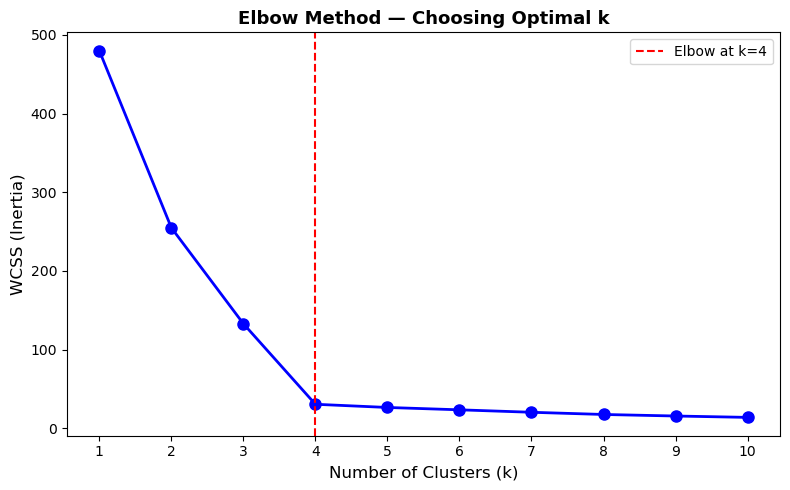

In [31]:
# Plot the elbow curve
plt.figure(figsize=(8, 5))
plt.plot(k_range, wcss, 'bo-', linewidth=2, markersize=8)
plt.axvline(x=4, color='red', linestyle='--', linewidth=1.5, label='Elbow at k=4')
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('WCSS (Inertia)', fontsize=12)
plt.title('Elbow Method — Choosing Optimal k', fontsize=13, fontweight='bold')
plt.xticks(k_range)
plt.legend()
plt.tight_layout()
plt.show()

**Reflection answer:** The elbow appears at **k = 4**. The WCSS drops steeply from k=1 to k=4, then the curve flattens. After k=4, adding more clusters only produces small reductions in WCSS — meaning the extra clusters are splitting existing natural groups rather than finding genuinely new ones. This is the point of diminishing returns.

## Step 6 - Confirm k with the Silhouette Score

In [32]:
# Calculate silhouette scores for k = 2 to 10
sil_scores  = []
k_range_sil = range(2, 11)

for k in k_range_sil:
    km     = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    score  = silhouette_score(X_scaled, labels)
    sil_scores.append(score)

print("k  →  Silhouette Score")
for k, s in zip(k_range_sil, sil_scores):
    print(f"k={k:2d}  →  {s:.4f}")

best_k = k_range_sil[np.argmax(sil_scores)]
print(f"\nBest k by silhouette score: {best_k}")

k  →  Silhouette Score
k= 2  →  0.4769
k= 3  →  0.5809
k= 4  →  0.7489
k= 5  →  0.6682
k= 6  →  0.5680
k= 7  →  0.4713
k= 8  →  0.3710
k= 9  →  0.3822
k=10  →  0.3950

Best k by silhouette score: 4


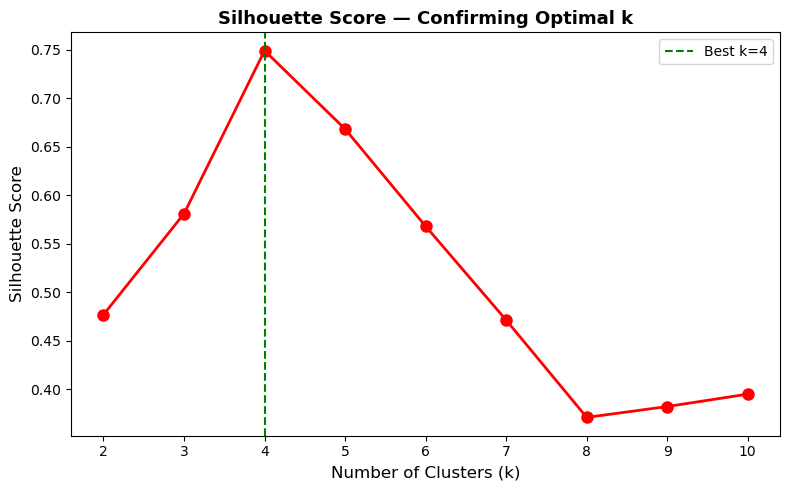

In [28]:
# Plot silhouette scores
plt.figure(figsize=(8, 5))
plt.plot(list(k_range_sil), sil_scores, 'ro-', linewidth=2, markersize=8)
plt.axvline(x=best_k, color='green', linestyle='--', linewidth=1.5,
            label=f'Best k={best_k}')
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.title('Silhouette Score — Confirming Optimal k', fontsize=13, fontweight='bold')
plt.xticks(list(k_range_sil))
plt.legend()
plt.tight_layout()
plt.show()

**Reflection answer:** Yes — the silhouette score peaks at **k = 4**, agreeing with the elbow method. Using two methods that point to the same answer gives much more confidence than relying on either alone. In practice, if the two methods disagreed, you would inspect both candidate k values visually and choose the one whose clusters are more interpretable.

## Step 7 - Fit the Final Model

In [33]:
# Fit the final model
kmeans_final = KMeans(n_clusters=best_k, init='k-means++', n_init=10, random_state=42)
df['segment'] = kmeans_final.fit_predict(X_scaled)

print(f"Inertia (WCSS): {kmeans_final.inertia_:.2f}")
print(f"\nMembers per segment:")
print(df['segment'].value_counts().sort_index())

Inertia (WCSS): 30.50

Members per segment:
segment
0    60
1    60
2    60
3    60
Name: count, dtype: int64


**Reflection answer:** The segments are roughly equal in size (around 60 each) because the data was designed that way. In real-world data, segments are rarely equal. A very large segment may represent the "average" customer who is less distinctive and harder to target. A very small segment may be a niche group worth special attention — or simply noise.

## Step 8 - Visualise the Clusters

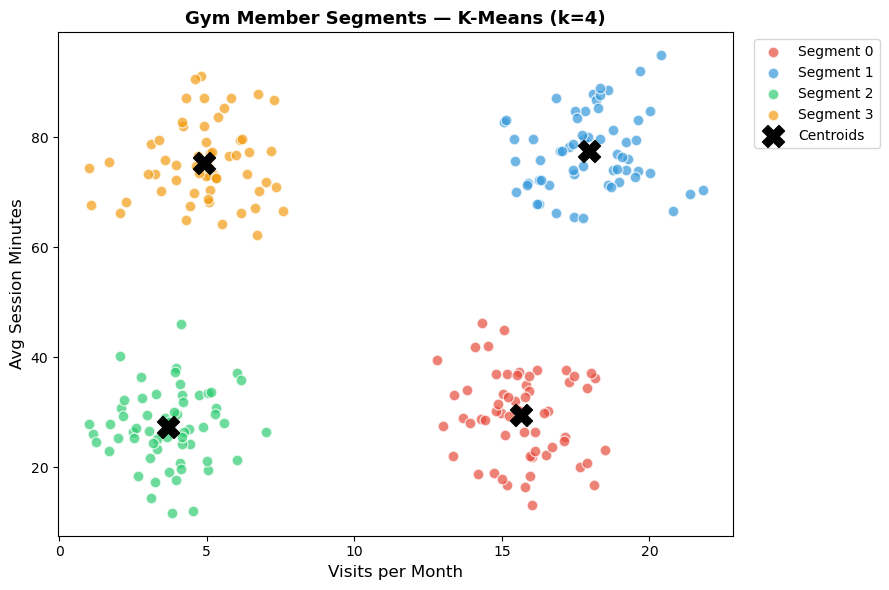

In [34]:
# Convert centroids back to original scale
centroids_original = scaler.inverse_transform(kmeans_final.cluster_centers_)

colours = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

plt.figure(figsize=(9, 6))

for seg in range(best_k):
    mask = df['segment'] == seg
    plt.scatter(df.loc[mask, 'visits_per_month'],
                df.loc[mask, 'avg_session_minutes'],
                c=colours[seg], label=f'Segment {seg}',
                alpha=0.7, edgecolors='white', s=60)

plt.scatter(centroids_original[:, 0], centroids_original[:, 1],
            c='black', marker='X', s=250, zorder=5, label='Centroids')

plt.xlabel('Visits per Month', fontsize=12)
plt.ylabel('Avg Session Minutes', fontsize=12)
plt.title('Gym Member Segments — K-Means (k=4)', fontsize=13, fontweight='bold')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Reflection answer:** The four clusters are clearly separated with very little overlap — the data was designed to have well-defined groups, so this is expected. Overlap between clusters would suggest that some members share characteristics of two groups and the boundary between them is not clean. This often happens in real data and is a known limitation of K-means, which always draws hard boundaries even when the true groups blend into each other.

## Step 9 - Summarise and Label Each Segment

In [35]:
# 1 & 2. Compute and print segment summary
summary = df.groupby('segment')[['visits_per_month', 'avg_session_minutes']].mean().round(1)
summary['count'] = df.groupby('segment')['segment'].count()
print(summary)

         visits_per_month  avg_session_minutes  count
segment                                              
0                    15.6                 29.5     60
1                    18.0                 77.4     60
2                     3.7                 27.3     60
3                     4.9                 75.3     60


In [36]:
# 3. Assign descriptive labels based on the means
# Low visits + short sessions  → Casual Visitors
# High visits + short sessions → Social Members
# Low visits + long sessions   → Dedicated Trainers
# High visits + long sessions  → Elite Members

def auto_label(row):
    high_visits = row['visits_per_month'] >= summary['visits_per_month'].median()
    long_session = row['avg_session_minutes'] >= summary['avg_session_minutes'].median()
    if not high_visits and not long_session: return 'Casual Visitors'
    if     high_visits and not long_session: return 'Social Members'
    if not high_visits and     long_session: return 'Dedicated Trainers'
    return 'Elite Members'

summary['label'] = summary.apply(auto_label, axis=1)
print(summary[['label', 'visits_per_month', 'avg_session_minutes', 'count']])

                      label  visits_per_month  avg_session_minutes  count
segment                                                                  
0            Social Members              15.6                 29.5     60
1             Elite Members              18.0                 77.4     60
2           Casual Visitors               3.7                 27.3     60
3        Dedicated Trainers               4.9                 75.3     60


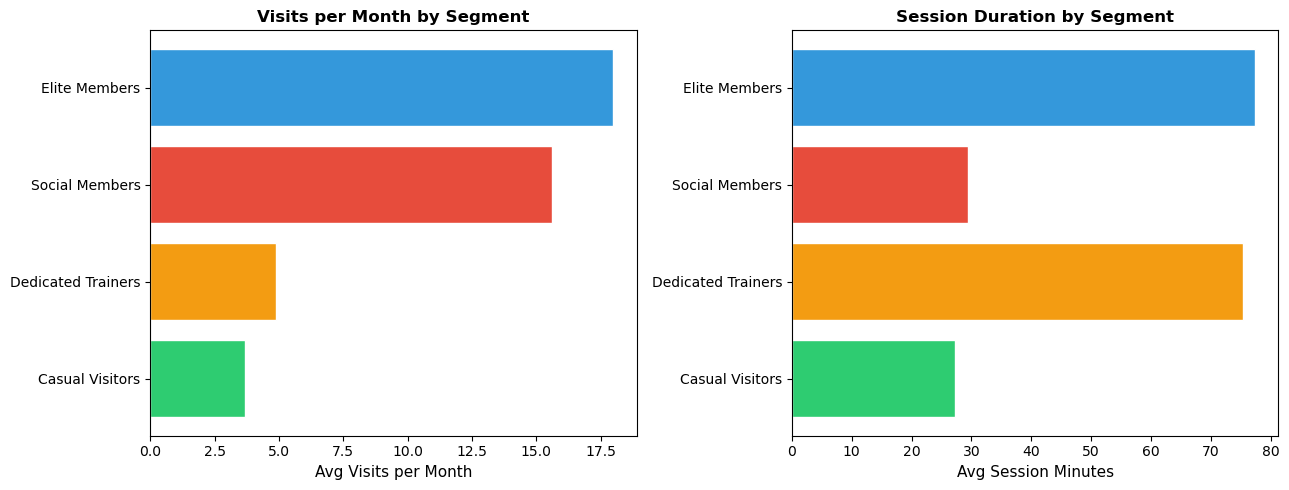

In [33]:
# 4. Side-by-side horizontal bar charts
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

seg_order = summary.sort_values('visits_per_month').index

axes[0].barh([summary.loc[s, 'label'] for s in seg_order],
             summary.loc[seg_order, 'visits_per_month'],
             color=[colours[s] for s in seg_order], edgecolor='white')
axes[0].set_xlabel('Avg Visits per Month', fontsize=11)
axes[0].set_title('Visits per Month by Segment', fontsize=12, fontweight='bold')

axes[1].barh([summary.loc[s, 'label'] for s in seg_order],
             summary.loc[seg_order, 'avg_session_minutes'],
             color=[colours[s] for s in seg_order], edgecolor='white')
axes[1].set_xlabel('Avg Session Minutes', fontsize=11)
axes[1].set_title('Session Duration by Segment', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

**Reflection answer:** The summary table closely matches the four groups visible in the Step 3 scatter plot — the algorithm successfully recovered the four natural groups embedded in the data. In real datasets, results are rarely this clean, and some segments may need more thought to name meaningfully.

## Step 10 — Reflect and Interpret

**Question 1 — Business Action (model answers):**

| Segment | Suggested Action |
|---------|------------------|
| Casual Visitors | Send re-engagement emails with a discounted monthly pass to increase visit frequency |
| Social Members | Promote group classes and social events — they already visit often but keep sessions short |
| Dedicated Trainers | Offer personal training packages and nutrition advice — they work hard but infrequently |
| Elite Members | Reward with a loyalty programme or VIP membership tier to retain them long-term |

---

**Question 2 — Scaling (model answer):**

Without scaling, `avg_session_minutes` (range ≈ 10–120) would dominate over `visits_per_month` (range ≈ 1–25) because its values are roughly 5× larger. A difference of 10 minutes would contribute more to the Euclidean distance than a difference of 5 visits, even though both changes are equally meaningful. The algorithm would effectively cluster mainly on session duration and largely ignore visit frequency — producing misleading segments.

---

**Question 3 — Limitations (model answer):**

In this dataset the clusters appear well-separated and roughly circular, so K-means is a good fit. However in real data clusters are rarely this clean. Members near the boundary between "Social" and "Elite" (high visits, moderate session length) could plausibly belong to either group. K-means draws a hard line and commits — it cannot express uncertainty. If the true groups overlapped significantly, a probabilistic method like Gaussian Mixture Models would be more appropriate.

---

**Question 4 — Extending the Analysis (model answer):**

Two additional features that would improve the segmentation:
1. **Age** — younger members may prefer group classes and social gym visits, while mature members may favour quieter, longer personal training sessions. Age would help split the Social Members into more actionable sub-groups.
2. **Membership tenure (months as a member)** — long-standing members behave differently from newcomers. A new Casual Visitor may simply not have found their routine yet, while a long-term Casual Visitor may genuinely be disengaged. Tenure helps distinguish these cases and informs very different retention strategies.

In [34]:
# Final summary
print("=" * 55)
print("  GYM MEMBER SEGMENTATION — PIPELINE SUMMARY")
print("=" * 55)
print(f"  Total members      : {len(df)}")
print(f"  Features used      : visits_per_month, avg_session_minutes")
print(f"  Optimal k          : {best_k}")
print(f"  Final WCSS         : {kmeans_final.inertia_:.2f}")
print(f"  Silhouette score   : {silhouette_score(X_scaled, df['segment']):.4f}")
print()
print("  Segment Summary:")
for _, row in summary.iterrows():
    print(f"    {row['label']:<22}: {int(row['count']):3d} members  "
          f"| {row['visits_per_month']:.1f} visits/mo  "
          f"| {row['avg_session_minutes']:.0f} min/session")
print("=" * 55)

  GYM MEMBER SEGMENTATION — PIPELINE SUMMARY
  Total members      : 240
  Features used      : visits_per_month, avg_session_minutes
  Optimal k          : 4
  Final WCSS         : 30.50
  Silhouette score   : 0.7489

  Segment Summary:
    Social Members        :  60 members  | 15.6 visits/mo  | 30 min/session
    Elite Members         :  60 members  | 18.0 visits/mo  | 77 min/session
    Casual Visitors       :  60 members  | 3.7 visits/mo  | 27 min/session
    Dedicated Trainers    :  60 members  | 4.9 visits/mo  | 75 min/session
